# Análise Exploratória de Dados — Stroke Prediction Dataset

Este notebook apresenta a etapa de **Data Understanding** do ciclo CRISP-DM para o projeto de previsão de ocorrência de AVC (*stroke*). O dataset utilizado foi obtido no Kaggle e contém informações demográficas, clínicas e comportamentais de pacientes.

O objetivo desta EDA é compreender a estrutura dos dados, identificar problemas de qualidade, analisar a distribuição da variável-alvo e levantar evidências que orientem a etapa de pré-processamento e modelagem.

A variável-alvo do projeto é `stroke`, que indica se o paciente teve AVC (`1`) ou não (`0`). Portanto, trata-se de um problema de **classificação binária**.

## 1. Carregamento das bibliotecas e do dataset

Nesta etapa, são importadas as bibliotecas necessárias para manipulação, visualização e análise inicial dos dados. Em seguida, o arquivo CSV é carregado a partir da pasta `data/raw`.

In [11]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/raw/healthcare-dataset-stroke-data.csv")

print("Dataset carregado com sucesso.")

Dataset carregado com sucesso.


## 2. Inspeção inicial

Nesta etapa, é realizada uma primeira verificação da estrutura do dataset. São analisados o formato da base, as primeiras linhas, os tipos das colunas, as informações gerais e as estatísticas descritivas.

Essa etapa permite identificar problemas iniciais, como valores ausentes, tipos de dados inadequados, presença de colunas sem valor preditivo e indícios de desbalanceamento na variável-alvo.

In [12]:
print("Formato do dataset:")
display(df.shape)

print("\nPrimeiras linhas:")
display(df.head())

print("\nTipos das colunas:")
display(df.dtypes)

print("\nInformações gerais:")
df.info()

print("\nEstatísticas descritivas:")
display(df.describe(include="all"))

Formato do dataset:


(5110, 12)


Primeiras linhas:


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1



Tipos das colunas:


id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object


Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB

Estatísticas descritivas:


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,5110.000000,5110,5110.000000,5110.000000,5110.000000,5110,5110,5110,5110.000000,4909.000000,5110,5110.000000
unique,NaN,3,NaN,NaN,NaN,2,5,2,NaN,NaN,4,NaN
top,NaN,Female,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,never smoked,NaN
freq,NaN,2994,NaN,NaN,NaN,3353,2925,2596,NaN,NaN,1892,NaN
mean,36517.829354,NaN,43.226614,0.097456,0.054012,NaN,NaN,NaN,106.147677,28.893237,NaN,0.048728
std,21161.721625,NaN,22.612647,0.296607,0.226063,NaN,NaN,NaN,45.283560,7.854067,NaN,0.215320
min,67.000000,NaN,0.080000,0.000000,0.000000,NaN,NaN,NaN,55.120000,10.300000,NaN,0.000000
25%,17741.250000,NaN,25.000000,0.000000,0.000000,NaN,NaN,NaN,77.245000,23.500000,NaN,0.000000
50%,36932.000000,NaN,45.000000,0.000000,0.000000,NaN,NaN,NaN,91.885000,28.100000,NaN,0.000000
75%,54682.000000,NaN,61.000000,0.000000,0.000000,NaN,NaN,NaN,114.090000,33.100000,NaN,0.000000


### Interpretação da inspeção inicial

O dataset possui **5.110 registros** e **12 colunas**, atendendo ao requisito mínimo do desafio de utilizar um dataset com pelo menos 1.000 instâncias. As variáveis incluem informações demográficas, clínicas e comportamentais dos pacientes, além da variável-alvo `stroke`.

A coluna `id` representa apenas um identificador único do registro e não possui significado preditivo direto. Por isso, ela será removida antes da modelagem.

Em relação aos tipos de dados, as variáveis numéricas foram carregadas corretamente como `int64` ou `float64`, enquanto as variáveis categóricas foram carregadas como `object`. Não foram identificados problemas evidentes de tipo nesta inspeção inicial.

A coluna `bmi` apresenta valores ausentes, com **4.909 valores não nulos** em um total de **5.110 registros**, ou seja, há **201 valores faltantes**. Essa ausência será tratada posteriormente dentro do `Pipeline` de modelagem com `SimpleImputer`, evitando vazamento de informação entre treino e teste.

A variável-alvo `stroke` possui média de aproximadamente **0,0487**, indicando que a classe positiva representa uma pequena parcela do dataset. Isso sugere um forte desbalanceamento entre pacientes sem AVC e com AVC, o que deverá ser considerado na escolha das métricas de avaliação.

## 3. Distribuição da variável-alvo

A variável-alvo deste projeto é `stroke`, que indica se o paciente teve AVC (`1`) ou não (`0`). Como o problema é de classificação binária, é necessário verificar a proporção entre as classes.

Essa análise é importante porque, caso exista grande diferença entre a quantidade de registros da classe `0` e da classe `1`, o dataset será considerado desbalanceado. Nesse cenário, métricas como acurácia podem ser pouco adequadas, pois um modelo poderia apresentar bom desempenho aparente apenas por prever a classe majoritária.

Por isso, a distribuição da variável-alvo será utilizada para orientar a escolha das métricas de avaliação na etapa de modelagem, como F1-macro, recall por classe, matriz de confusão e ROC-AUC.

,classe,quantidade,percentual
0,0,4861,95.13
1,1,249,4.87


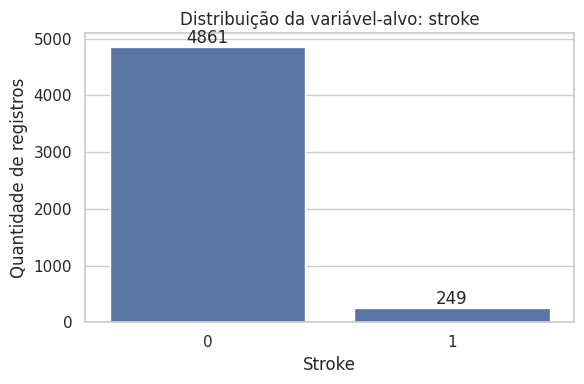

In [13]:
target_counts = df["stroke"].value_counts().sort_index()
target_percent = df["stroke"].value_counts(normalize=True).sort_index() * 100

target_distribution = pd.DataFrame({
    "classe": target_counts.index,
    "quantidade": target_counts.values,
    "percentual": target_percent.round(2).values
})

display(target_distribution)

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="stroke", order=[0, 1])

plt.title("Distribuição da variável-alvo: stroke")
plt.xlabel("Stroke")
plt.ylabel("Quantidade de registros")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### Leitura do resultado

- Classe `0`: 4.861 registros (**95,13%**)
- Classe `1`: 249 registros (**4,87%**)

O alvo está fortemente desbalanceado.

Isso é ruim para a modelagem porque a acurácia pode ficar artificialmente alta se o modelo aprender a prever quase sempre a classe `0`.

Na modelagem, a avaliação deve priorizar métricas mais adequadas para desbalanceamento:

- F1-macro
- recall da classe `1`
- matriz de confusão
- ROC-AUC

## 4. Valores ausentes, duplicatas e valores únicos

Nesta etapa foram verificados:

- valores ausentes;
- registros duplicados;
- quantidade de valores únicos por coluna.

Esses pontos ajudam a identificar problemas de qualidade e decisões necessárias antes da modelagem.

In [14]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_table = pd.DataFrame({
    "valores_ausentes": missing,
    "percentual": missing_percent.round(2)
})

print("Valores ausentes por coluna:")
display(missing_table)

print("\nQuantidade de registros duplicados:")
display(df.duplicated().sum())

print("\nQuantidade de valores únicos por coluna:")
display(df.nunique().sort_values(ascending=False))

Valores ausentes por coluna:


,valores_ausentes,percentual
bmi,201,3.93
id,0,0.00
age,0,0.00
gender,0,0.00
hypertension,0,0.00
heart_disease,0,0.00
work_type,0,0.00
ever_married,0,0.00
Residence_type,0,0.00
avg_glucose_level,0,0.00



Quantidade de registros duplicados:


np.int64(0)


Quantidade de valores únicos por coluna:


id                   5110
avg_glucose_level    3979
bmi                   418
age                   104
work_type               5
smoking_status          4
gender                  3
hypertension            2
Residence_type          2
ever_married            2
heart_disease           2
stroke                  2
dtype: int64

### Leitura do resultado

- `bmi` tem **201 valores ausentes** (**3,93%**).
- As demais colunas não têm valores ausentes.
- Não há registros duplicados.
- `id` tem **5.110 valores únicos**, então funciona apenas como identificador.
- As variáveis categóricas têm baixa cardinalidade.

Decisões:

- remover `id` antes da modelagem;
- tratar `bmi` dentro do `Pipeline`, usando imputação pela mediana;
- codificar variáveis categóricas com `OneHotEncoder`.

## 5. Distribuição das variáveis categóricas

Aqui são analisadas as frequências das categorias.

Objetivo:

- identificar categorias raras;
- verificar possíveis inconsistências;
- entender quais variáveis precisam de codificação antes da modelagem.


Distribuição de gender:


gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

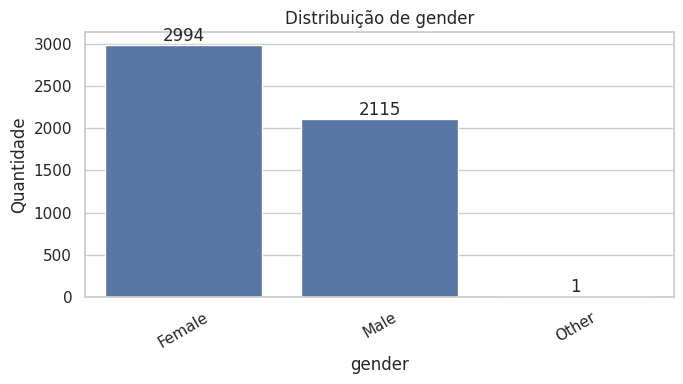


Distribuição de ever_married:


ever_married
Yes    3353
No     1757
Name: count, dtype: int64

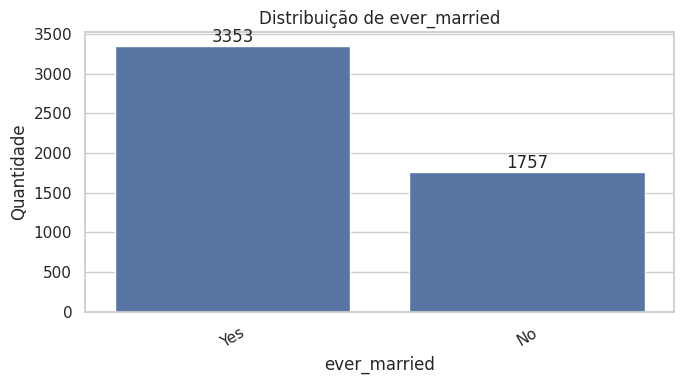


Distribuição de work_type:


work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

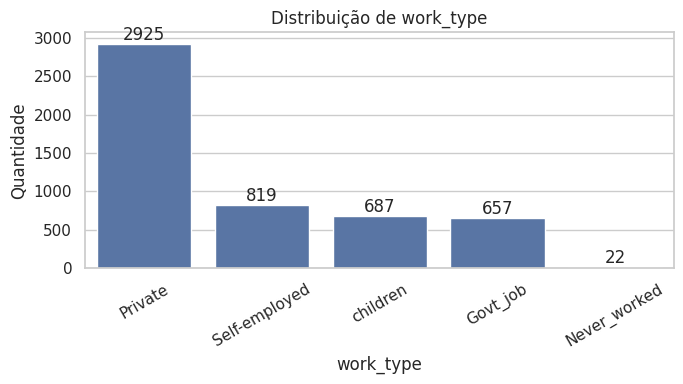


Distribuição de Residence_type:


Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

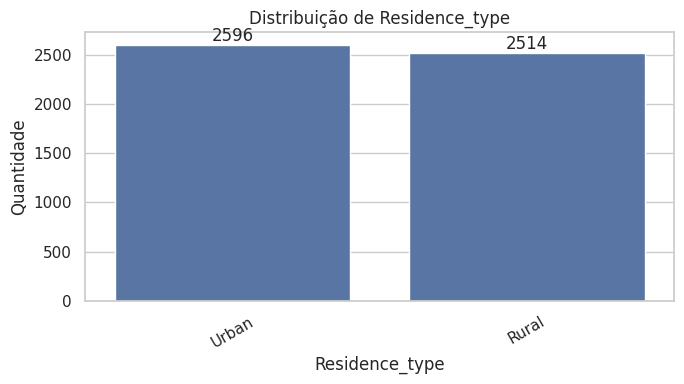


Distribuição de smoking_status:


smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64

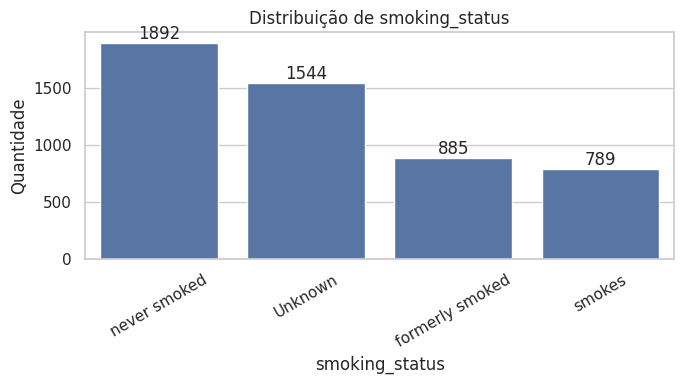

In [15]:
cat_cols = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

for col in cat_cols:
    print(f"\nDistribuição de {col}:")
    display(df[col].value_counts(dropna=False))
    
    plt.figure(figsize=(7, 4))
    ax = sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Distribuição de {col}")
    plt.xlabel(col)
    plt.ylabel("Quantidade")
    plt.xticks(rotation=30)

    for container in ax.containers:
        ax.bar_label(container)

    plt.tight_layout()
    plt.show()

### Leitura do resultado

- `gender`: predominância de `Female` e apenas **1 registro** como `Other`.
- `ever_married`: maioria dos pacientes já foi casada.
- `work_type`: maior concentração em `Private`; `Never_worked` aparece pouco.
- `Residence_type`: distribuição equilibrada entre `Urban` e `Rural`.
- `smoking_status`: muitos registros como `Unknown`, então essa categoria não deve ser simplesmente removida.

Decisões:

- remover o único registro com `gender = Other`, por ser uma categoria extremamente rara;
- manter `Unknown` em `smoking_status` como categoria própria;
- aplicar `OneHotEncoder` nas variáveis categóricas na modelagem.

## 6. Distribuição das variáveis numéricas

Nesta etapa foram analisadas as variáveis numéricas contínuas:

- `age`
- `avg_glucose_level`
- `bmi`

Objetivo:

- observar concentração dos valores;
- identificar assimetria;
- verificar possíveis outliers;
- entender se alguma variável precisa de tratamento no pré-processamento.

,age,avg_glucose_level,bmi
count,5110.000000,5110.000000,4909.000000
mean,43.226614,106.147677,28.893237
std,22.612647,45.283560,7.854067
min,0.080000,55.120000,10.300000
25%,25.000000,77.245000,23.500000
50%,45.000000,91.885000,28.100000
75%,61.000000,114.090000,33.100000
max,82.000000,271.740000,97.600000


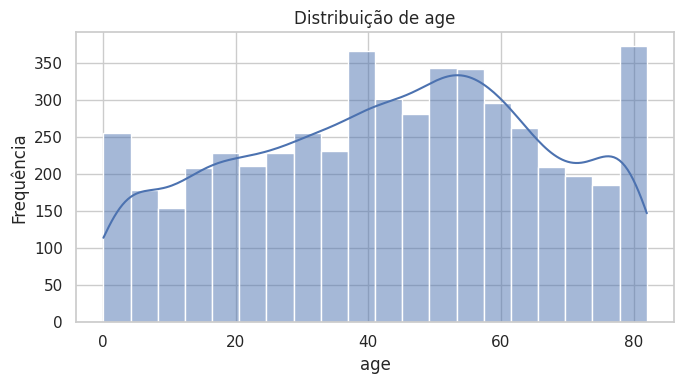

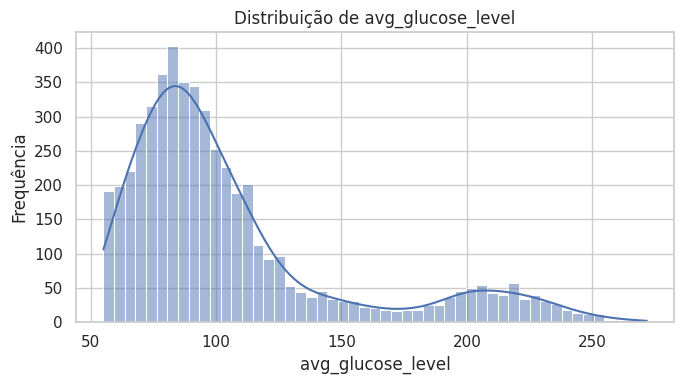

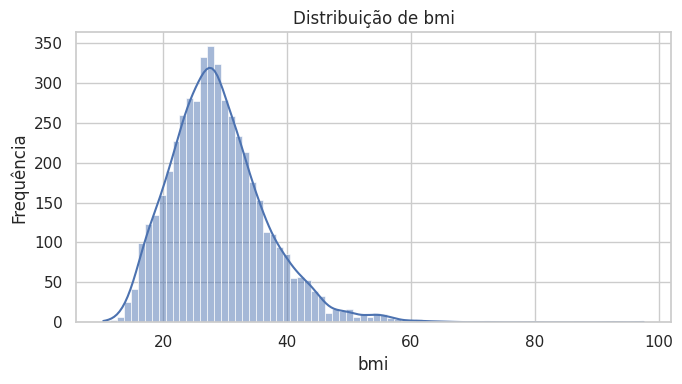

In [16]:
num_cols = ["age", "avg_glucose_level", "bmi"]

display(df[num_cols].describe())

for col in num_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"Distribuição de {col}")
    plt.xlabel(col)
    plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()

### Leitura do resultado

- `age`: varia de **0,08** a **82 anos**. A idade está em escala plausível.
- `avg_glucose_level`: média **106,15**, mediana **91,89** e máximo **271,74**. Há assimetria à direita e possíveis valores altos.
- `bmi`: média **28,89**, mediana **28,10** e máximo **97,60**. Há valores altos e 201 ausentes já identificados.

Indicações:

- `avg_glucose_level` e `bmi` podem ter outliers.
- `bmi` será imputado dentro do `Pipeline`.
- As variáveis numéricas serão padronizadas na modelagem com `StandardScaler`.

## 7. Verificação de outliers

Nesta etapa foi usado o método IQR para identificar valores extremos nas variáveis numéricas.

Objetivo:

- verificar possíveis valores fora do padrão;
- decidir se os outliers devem ser removidos, mantidos ou tratados no pipeline.

,variavel,limite_inferior,limite_superior,quantidade_outliers,percentual
0,age,-29.00,115.00,0,0.00
1,avg_glucose_level,21.98,169.36,627,12.27
2,bmi,9.10,47.50,110,2.15


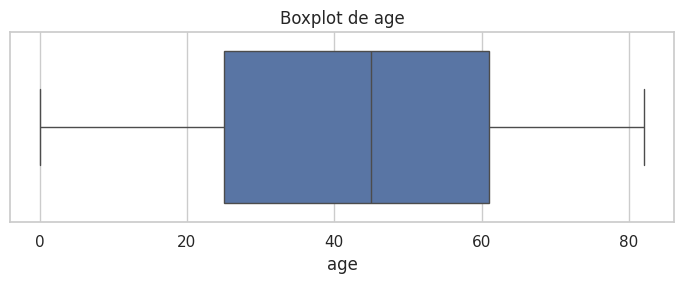

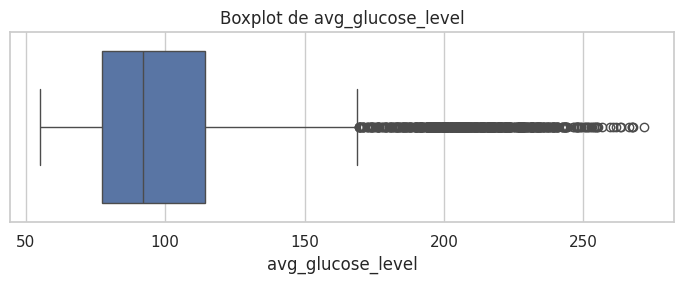

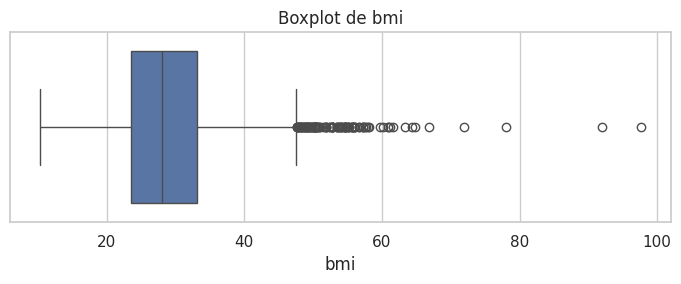

In [17]:
num_cols = ["age", "avg_glucose_level", "bmi"]

outlier_summary = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]
    
    outlier_summary.append({
        "variavel": col,
        "limite_inferior": round(lower_limit, 2),
        "limite_superior": round(upper_limit, 2),
        "quantidade_outliers": outliers.shape[0],
        "percentual": round((outliers.shape[0] / df.shape[0]) * 100, 2)
    })

outlier_table = pd.DataFrame(outlier_summary)
display(outlier_table)

for col in num_cols:
    plt.figure(figsize=(7, 3))
    sns.boxplot(data=df, x=col)
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

### Leitura do resultado

- `age`: não apresentou outliers pelo IQR.
- `avg_glucose_level`: **627 outliers** (**12,27%**).
- `bmi`: **110 outliers** (**2,15%**).

Indicações:

- Os valores altos de glicose e IMC podem ser clinicamente relevantes para AVC.
- Não vou remover esses outliers automaticamente.
- O tratamento principal será manter os dados e usar modelos capazes de lidar com variações.
- `bmi` continua sendo tratado no `Pipeline` por imputação da mediana.

## 8. Verificação de valores impossíveis

Nesta etapa foram verificados valores fora de faixas esperadas.

Pontos observados:

- idade negativa ou acima de 120;
- glicose menor ou igual a zero;
- IMC menor ou igual a zero;
- categorias inesperadas.

In [18]:
checks = {
    "idade_negativa": (df["age"] < 0).sum(),
    "idade_acima_120": (df["age"] > 120).sum(),
    "glicose_menor_igual_zero": (df["avg_glucose_level"] <= 0).sum(),
    "bmi_menor_igual_zero": (df["bmi"] <= 0).sum()
}

checks_table = pd.DataFrame.from_dict(checks, orient="index", columns=["quantidade"])
display(checks_table)

print("Categorias em gender:")
display(df["gender"].value_counts(dropna=False))

print("Categorias em ever_married:")
display(df["ever_married"].value_counts(dropna=False))

print("Categorias em work_type:")
display(df["work_type"].value_counts(dropna=False))

print("Categorias em Residence_type:")
display(df["Residence_type"].value_counts(dropna=False))

print("Categorias em smoking_status:")
display(df["smoking_status"].value_counts(dropna=False))

,quantidade
idade_negativa,0
idade_acima_120,0
glicose_menor_igual_zero,0
bmi_menor_igual_zero,0


Categorias em gender:


gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

Categorias em ever_married:


ever_married
Yes    3353
No     1757
Name: count, dtype: int64

...

work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

Categorias em Residence_type:


Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

Categorias em smoking_status:


smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64

### Leitura do resultado

- Não há idade negativa ou acima de 120 anos.
- Não há glicose menor ou igual a zero.
- Não há IMC menor ou igual a zero.

Indicação:

- Não foi necessário remover registros por valores numericamente impossíveis.
- Os principais problemas permanecem: `bmi` ausente, outliers em `avg_glucose_level` e `bmi`, e categoria rara em `gender`.

## 9. Relação entre variáveis numéricas e a variável-alvo

Nesta etapa, as variáveis numéricas são comparadas com `stroke`.

Objetivo:

- verificar se pacientes com AVC apresentam diferenças em idade, glicose média e IMC;
- identificar variáveis com possível utilidade para a modelagem.

age                      avg_glucose_level                         \
       count   mean median    std             count    mean  median    std   
stroke                                                                       
0       4861  41.97   43.0  22.29              4861  104.80   91.47  43.85   
1        249  67.73   71.0  12.73               249  132.54  105.22  61.92   

         bmi                      
       count   mean median   std  
stroke                            
0       4700  28.82   28.0  7.91  
1        209  30.47   29.7  6.33

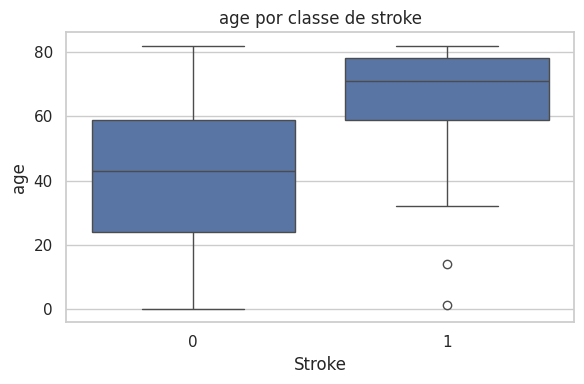

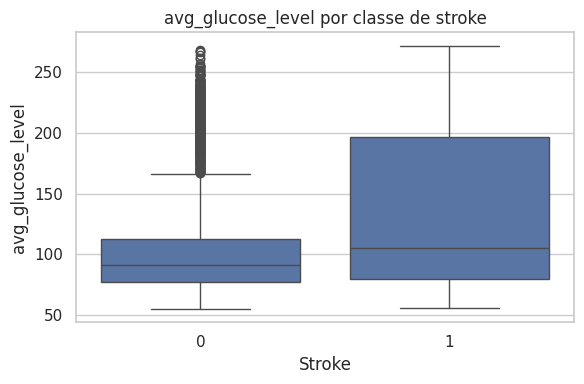

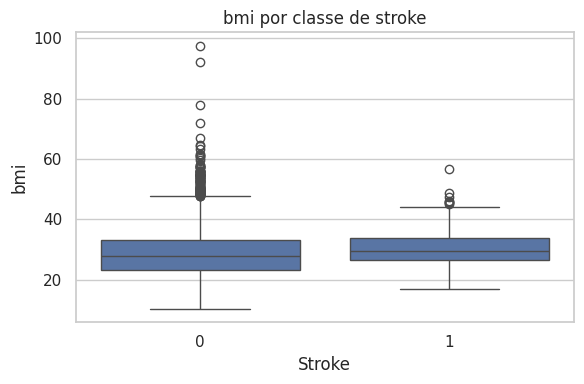

In [19]:
num_cols = ["age", "avg_glucose_level", "bmi"]

numeric_target_summary = df.groupby("stroke")[num_cols].agg(["count", "mean", "median", "std"]).round(2)
display(numeric_target_summary)

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x="stroke", y=col)
    plt.title(f"{col} por classe de stroke")
    plt.xlabel("Stroke")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

### Leitura do resultado

- `age`: pacientes com AVC têm idade média e mediana bem maiores.
- `avg_glucose_level`: pacientes com AVC também apresentam glicose média mais alta.
- `bmi`: diferença menor entre os grupos.

Indicações:

- `age` parece ser uma variável importante para prever AVC.
- `avg_glucose_level` também pode contribuir para o modelo.
- `bmi` tem relação mais fraca, mas será mantida.

## 10. Matriz de correlação

Nesta etapa foi analisada a correlação entre variáveis numéricas.

Objetivo:

- verificar relação linear entre as variáveis;
- observar quais variáveis numéricas têm maior associação com `stroke`;
- identificar possível multicolinearidade.

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
id,1.000,0.004,0.004,-0.001,0.001,0.003,0.006
age,0.004,1.000,0.276,0.264,0.238,0.333,0.245
hypertension,0.004,0.276,1.000,0.108,0.174,0.168,0.128
heart_disease,-0.001,0.264,0.108,1.000,0.162,0.041,0.135
avg_glucose_level,0.001,0.238,0.174,0.162,1.000,0.176,0.132
bmi,0.003,0.333,0.168,0.041,0.176,1.000,0.042
stroke,0.006,0.245,0.128,0.135,0.132,0.042,1.000


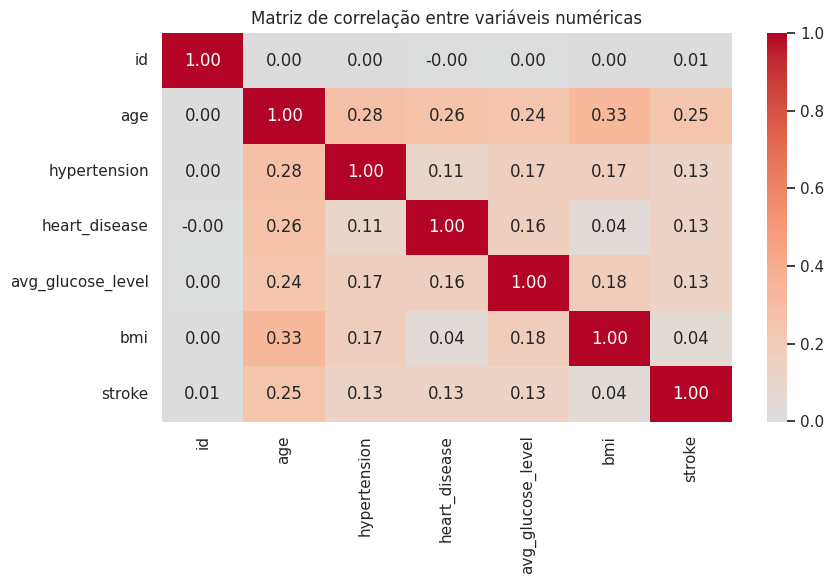

Correlação com stroke:


stroke               1.000
age                  0.245
heart_disease        0.135
avg_glucose_level    0.132
hypertension         0.128
bmi                  0.042
id                   0.006
Name: stroke, dtype: float64

In [20]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

corr_matrix = numeric_df.corr()

display(corr_matrix.round(3))

plt.figure(figsize=(9, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlação entre variáveis numéricas")
plt.tight_layout()
plt.show()

print("Correlação com stroke:")
display(corr_matrix["stroke"].sort_values(ascending=False).round(3))

### Leitura do resultado

- `age` teve a maior correlação com `stroke`: **0,245**.
- `heart_disease`, `avg_glucose_level` e `hypertension` tiveram correlação positiva, mas baixa.
- `bmi` apresentou correlação muito baixa com `stroke`.
- `id` não tem relação útil com o alvo.

Indicações:

- não há alta correlação linear com `stroke`;
- `age` parece ser a variável numérica mais relevante;
- `id` será removido antes da modelagem;
- não foi observada multicolinearidade forte entre as variáveis numéricas.

## 11. Relação entre variáveis categóricas/binárias e AVC

Nesta etapa foi calculada a taxa de AVC por grupo.

Objetivo:

- comparar a proporção de AVC em cada categoria;
- verificar se hipertensão, doença cardíaca, casamento, trabalho, residência, gênero e tabagismo indicam diferenças relevantes.

In [21]:
cat_target_cols = [
    "gender",
    "hypertension",
    "heart_disease",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status"
]

for col in cat_target_cols:
    print(f"\nTaxa de AVC por categoria: {col}")
    
    summary = (
        df.groupby(col)["stroke"]
        .agg(["count", "sum", "mean"])
        .rename(columns={
            "count": "total_registros",
            "sum": "casos_avc",
            "mean": "taxa_avc"
        })
    )
    
    summary["taxa_avc"] = (summary["taxa_avc"] * 100).round(2)
    
    display(summary.sort_values("taxa_avc", ascending=False))


Taxa de AVC por categoria: gender


,total_registros,casos_avc,taxa_avc
gender,,,
Male,2115,108,5.11
Female,2994,141,4.71
Other,1,0,0.00



Taxa de AVC por categoria: hypertension


,total_registros,casos_avc,taxa_avc
hypertension,,,
1,498,66,13.25
0,4612,183,3.97



Taxa de AVC por categoria: heart_disease


...

,total_registros,casos_avc,taxa_avc
work_type,,,
Self-employed,819,65,7.94
Private,2925,149,5.09
Govt_job,657,33,5.02
children,687,2,0.29
Never_worked,22,0,0.00



Taxa de AVC por categoria: Residence_type


,total_registros,casos_avc,taxa_avc
Residence_type,,,
Urban,2596,135,5.20
Rural,2514,114,4.53



Taxa de AVC por categoria: smoking_status


,total_registros,casos_avc,taxa_avc
smoking_status,,,
formerly smoked,885,70,7.91
smokes,789,42,5.32
never smoked,1892,90,4.76
Unknown,1544,47,3.04


### Leitura do resultado

- `hypertension = 1`: taxa de AVC maior que em pacientes sem hipertensão.
- `heart_disease = 1`: maior taxa de AVC entre os grupos analisados.
- `ever_married = Yes`: taxa maior, mas pode estar relacionada à idade.
- `work_type`: `Self-employed` tem taxa maior; `children` tem taxa muito baixa.
- `Residence_type`: diferença pequena entre urbano e rural.
- `smoking_status`: `formerly smoked` apresenta maior taxa.

Indicações:

- `hypertension` e `heart_disease` parecem variáveis importantes.
- `ever_married`, `work_type` e `smoking_status` podem ajudar, mas devem ser interpretadas com cuidado.
- Não é possível afirmar causalidade; a análise mostra apenas associação no dataset.

## 12. Visualização da taxa de AVC por categoria

Nesta etapa, a taxa de AVC foi visualizada por categoria.

Objetivo:

- destacar diferenças entre grupos;
- facilitar a leitura dos achados;
- apoiar a escolha das variáveis para a modelagem.

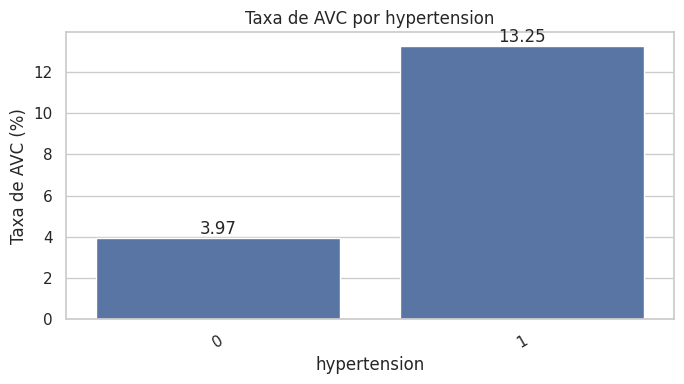

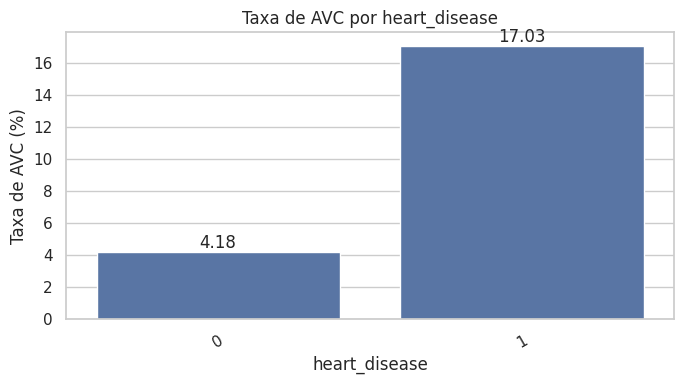

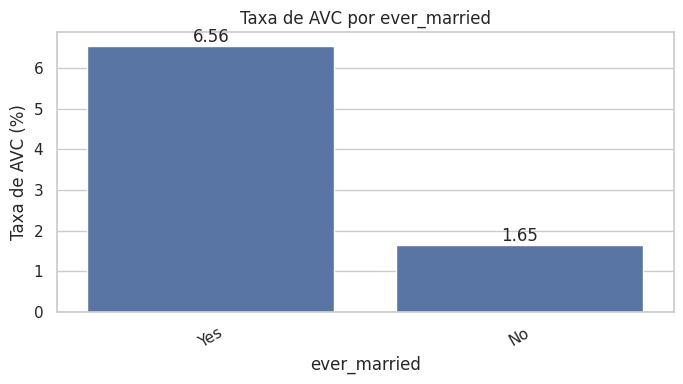

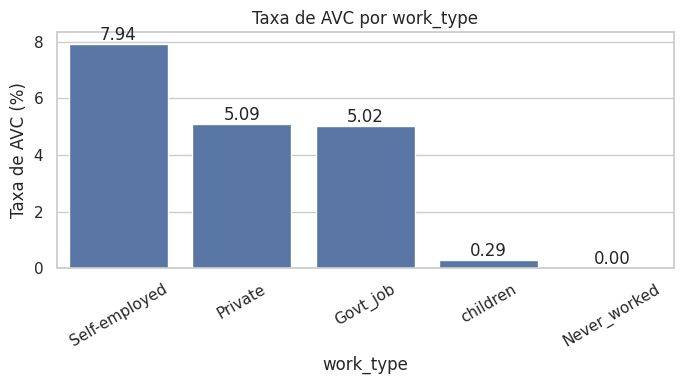

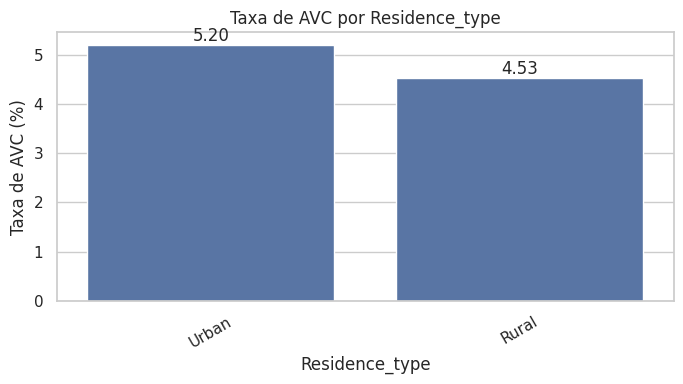

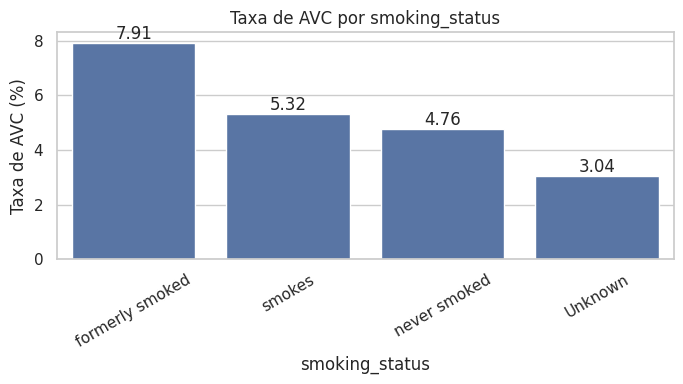

In [22]:
cat_target_cols = [
    "hypertension",
    "heart_disease",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status"
]

for col in cat_target_cols:
    rate_df = (
        df.groupby(col)["stroke"]
        .mean()
        .reset_index()
        .rename(columns={"stroke": "taxa_avc"})
    )
    
    rate_df["taxa_avc"] = rate_df["taxa_avc"] * 100
    rate_df = rate_df.sort_values("taxa_avc", ascending=False)
    
    plt.figure(figsize=(7, 4))
    ax = sns.barplot(data=rate_df, x=col, y="taxa_avc")
    
    plt.title(f"Taxa de AVC por {col}")
    plt.xlabel(col)
    plt.ylabel("Taxa de AVC (%)")
    plt.xticks(rotation=30)
    
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f")
    
    plt.tight_layout()
    plt.show()

## 13. Decisões de limpeza

Com base na EDA, foram definidas as principais decisões antes da modelagem:

- remover `id`, pois é apenas identificador;
- remover o registro com `gender = Other`, por ser uma categoria única;
- manter `Unknown` em `smoking_status`, pois representa muitos registros;
- não remover outliers de glicose e IMC automaticamente;
- tratar `bmi` ausente dentro do `Pipeline`, evitando data leakage.

In [23]:
df_model = df.copy()

# Remoção de identificador sem valor preditivo
df_model = df_model.drop(columns=["id"])

# Remoção da categoria extremamente rara
df_model = df_model[df_model["gender"] != "Other"].copy()

print("Formato original:", df.shape)
print("Formato após limpeza estrutural:", df_model.shape)

print("\nDistribuição de gender após limpeza:")
display(df_model["gender"].value_counts())

print("\nValores ausentes após limpeza estrutural:")
display(df_model.isnull().sum().sort_values(ascending=False))

Formato original: (5110, 12)
Formato após limpeza estrutural: (5109, 11)

Distribuição de gender após limpeza:


gender
Female    2994
Male      2115
Name: count, dtype: int64


Valores ausentes após limpeza estrutural:


bmi                  201
age                    0
gender                 0
hypertension           0
heart_disease          0
work_type              0
ever_married           0
Residence_type         0
avg_glucose_level      0
smoking_status         0
stroke                 0
dtype: int64

### Leitura da limpeza estrutural

- `id` foi removido por ser apenas identificador.
- O único registro com `gender = Other` foi removido.
- A base passou de **5.110 × 12** para **5.109 × 11**.
- `bmi` continua com **201 valores ausentes**.

Indicação:

- a imputação de `bmi` será feita apenas no `Pipeline` de modelagem;
- a base processada será salva sem preenchimento manual dos ausentes.

In [24]:
from pathlib import Path

processed_path = Path("../data/processed/stroke_limpo.csv")
processed_path.parent.mkdir(parents=True, exist_ok=True)

df_model.to_csv(processed_path, index=False)

print(f"Arquivo salvo em: {processed_path}")
print("Formato salvo:", df_model.shape)

Arquivo salvo em: ../data/processed/stroke_limpo.csv
Formato salvo: (5109, 11)


## 14. Insights finais da EDA

Principais achados:

1. A variável-alvo `stroke` está fortemente desbalanceada:
   - classe `0`: 95,13%;
   - classe `1`: 4,87%.

2. A coluna `bmi` possui 201 valores ausentes.
   - A imputação será feita no `Pipeline`, não manualmente na EDA.

3. `age` foi a variável numérica com maior associação com AVC.
   - Pacientes com AVC apresentaram média e mediana de idade maiores.

4. `avg_glucose_level`, `hypertension` e `heart_disease` também mostraram diferenças entre os grupos.
   - Essas variáveis serão mantidas na modelagem.

5. `id` não tem valor preditivo e foi removida.
   - O registro com `gender = Other` também foi removido por ser uma categoria única.

Decisões para a modelagem:

- usar `F1-macro` como métrica principal;
- acompanhar também recall da classe `1`, matriz de confusão e ROC-AUC;
- usar `SimpleImputer` para tratar `bmi`;
- usar `StandardScaler` nas numéricas;
- usar `OneHotEncoder` nas categóricas;
- comparar pelo menos 3 modelos.

In [25]:
print("Base final para modelagem:")
display(df_model.head())

print("Formato final:")
display(df_model.shape)

print("Colunas finais:")
display(df_model.columns.tolist())

print("Valores ausentes finais:")
display(df_model.isnull().sum().sort_values(ascending=False))

Base final para modelagem:


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


Formato final:


(5109, 11)

Colunas finais:


['gender',
 'age',
 'hypertension',
 'heart_disease',
 'ever_married',
 'work_type',
 'Residence_type',
 'avg_glucose_level',
 'bmi',
 'smoking_status',
 'stroke']

Valores ausentes finais:


bmi                  201
age                    0
gender                 0
hypertension           0
heart_disease          0
work_type              0
ever_married           0
Residence_type         0
avg_glucose_level      0
smoking_status         0
stroke                 0
dtype: int64